In [51]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

def integrand(w):
    fw = 1/ np.sqrt(1 + w**4)
    return fw

def path_func(t, z):
    return t*z

In [35]:
def contour(r, theta):
    return (1- 2 * r**2* np.cos(theta) + r**4)/(1-r**2)

def compute_contour(r, theta):
    return contour(r, theta)

def path(r, theta):
    return r * np.exp(1j * theta)

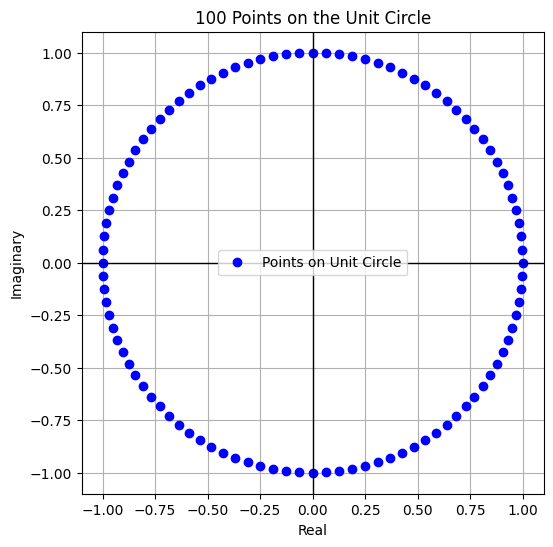

In [65]:
# unit circle

def unit_circle_points(N):
    return np.exp(2j * np.pi * np.arange(N) / N)

points = unit_circle_points(100)
plt.figure(figsize=(6, 6))
plt.plot(np.real(points), np.imag(points), 'bo', label='Points on Unit Circle')
plt.title('100 Points on the Unit Circle')
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.gca().set_aspect('equal', adjustable='box')  # Equal scaling for both axes
plt.grid(True)
plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.legend()
plt.show()

In [37]:
def complex_integral(z):
    def integrand_on_path(t):
        w = path_func(t, z)
        return integrand(w)

    real_integral_res, error = quad(lambda t:np.real(integrand_on_path(t)), 0, 1)
    imag_integral_res, _ = quad(lambda t:np.imag(integrand_on_path(t)), 0, 1)
    return real_integral_res, imag_integral_res


In [39]:
def evaluate_integral():
    total_integral = 0.0

    for r in np.linspace(0, 0.99, 100):
        for theta in np.linspace(0, np.pi/4, 100):
            z = compute_contour(r, theta)
            real_part, imaginary_part = complex_integral(z)
            total_integral += real_part + (1j * imaginary_part)

    return total_integral

evaluate_integral()

In [59]:
# Test case
# Evaluate unit circle on that integrand. We should get a sqaure

def unit_circle_on_itegrand(z):
    result_real = []
    result_imag = []
    for z_val in z:
        real_part, imaginary_part = complex_integral(z_val)
        result_real.append(real_part)
        result_imag.append(imaginary_part)
    return result_real, result_imag


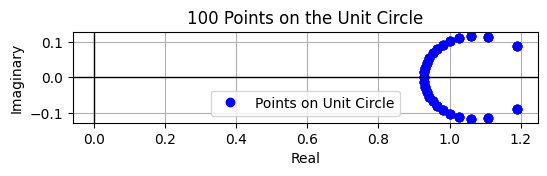

In [73]:
test_u_circle = unit_circle_on_itegrand(unit_circle_points(100))

plt.figure(figsize=(6, 6))
plt.plot(test_u_circle[0], test_u_circle[1], 'bo', label='Points on Unit Circle')
plt.title('100 Points on the Unit Circle')
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.gca().set_aspect('equal', adjustable='box')  # Equal scaling for both axes
plt.grid(True)
plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.legend()
plt.show()